# Probabilistic Dirichlet search algorithm

In [1]:
import os
import io
import random
import copy
import torch
import json
import pickle
import contextlib
import numpy as np
from operator import itemgetter
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax as _
from mylib import probtools
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from constants import ACTIONS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [3]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[33]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [4]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()
scene_height = scene_dims[1]  # Height of the scene

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the topdown map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_map = myutils.retain_largest_white_chunk(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the grid map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map = myutils.map_to_rgb(grid_map)
grid_map = myutils.retain_largest_white_chunk(grid_map)
grid_resolution = grid_map.shape[:2]

# Free positions
grid_free_cells, map_free_cells, world_free_coords = [], [], []

# Occupied positions
grid_occ_cells, map_occ_cells, world_occ_coords = [], [], []

# Compute free and occupied
for grid_x in range(grid_resolution[0]):
    for grid_y in range(grid_resolution[1]):
        # Convert grid coordinates to real world coordinates and then to top-down map coordinates
        real_world_z, real_world_x = maps.from_grid(grid_x, grid_y, grid_resolution, pathfinder=sim.pathfinder)
        map_x, map_y = maps.to_grid(real_world_z, real_world_x, topdown_resolution, pathfinder=sim.pathfinder)

        if not sim.pathfinder.is_navigable([real_world_x, 0.0, real_world_z]) or not topdown_map[map_x, map_y, 0] == 255 or not grid_map[grid_x, grid_y, 0] == 255:
            grid_map[grid_x, grid_y, :] = [128, 128, 128]  # Grey out non-navigable

# Filter again
grid_map = myutils.retain_largest_white_chunk(grid_map)

# Compute free and occupied
for grid_x in range(grid_resolution[0]):
    for grid_y in range(grid_resolution[1]):
        # Convert grid coordinates to real world coordinates and then to top-down map coordinates
        real_world_z, real_world_x = maps.from_grid(grid_x, grid_y, grid_resolution, pathfinder=sim.pathfinder)
        map_x, map_y = maps.to_grid(real_world_z, real_world_x, topdown_resolution, pathfinder=sim.pathfinder)

        if sim.pathfinder.is_navigable([real_world_x, 0.0, real_world_z]) and topdown_map[map_x, map_y, 0] == 255 and grid_map[grid_x, grid_y, 0] == 255:
            world_free_coords.append([real_world_x, 0.0, real_world_z])
            map_free_cells.append([map_x, map_y])
            grid_free_cells.append([grid_x, grid_y])
        else:
            world_occ_coords.append([real_world_x, 0.0, real_world_z])
            map_occ_cells.append([map_x, map_y])
            grid_occ_cells.append([grid_x, grid_y])

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)

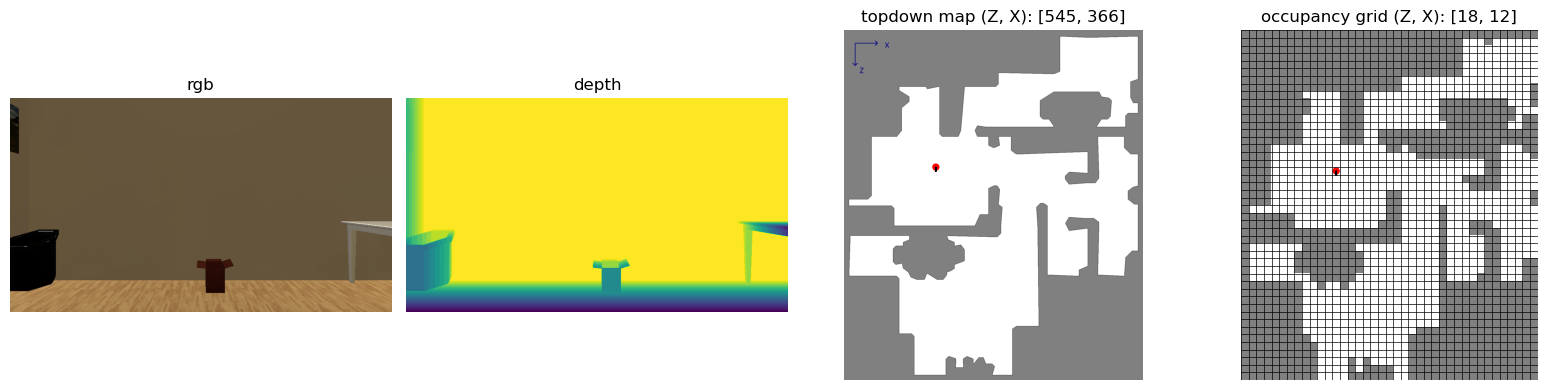

In [28]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

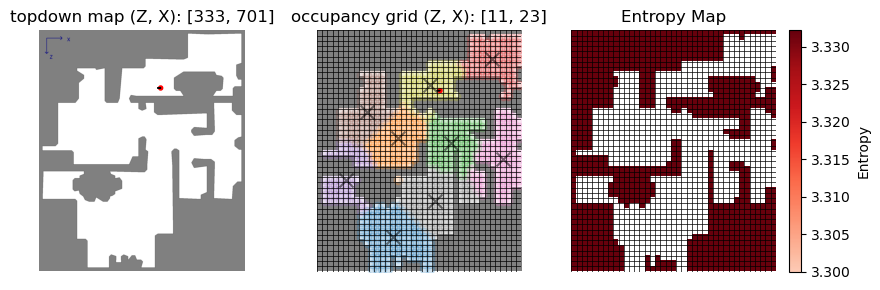

Cluster 0: Distance = 45.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 1: Distance = 17.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 2: Distance = 24.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 3: Distance = 16.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 4: Distance = 55.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 5: Distance = 18.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 6: Distance = 37.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 7: Distance = 32.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 8: Distance = 3.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04

Cluster 0: Distance = 0.81, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.10
Cluster 1: Distance = 0.27, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.37
Cluster 2: Distance = 0.40, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.30
Cluster 3: Distance = 0.25, Avg Entropy = 0

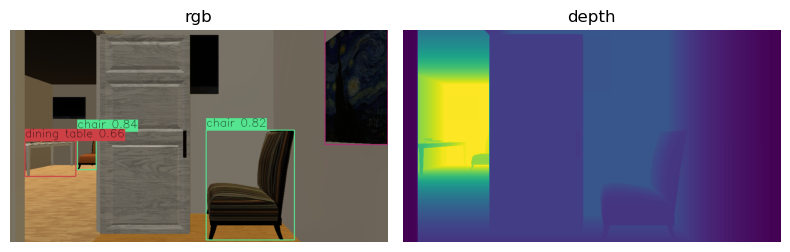

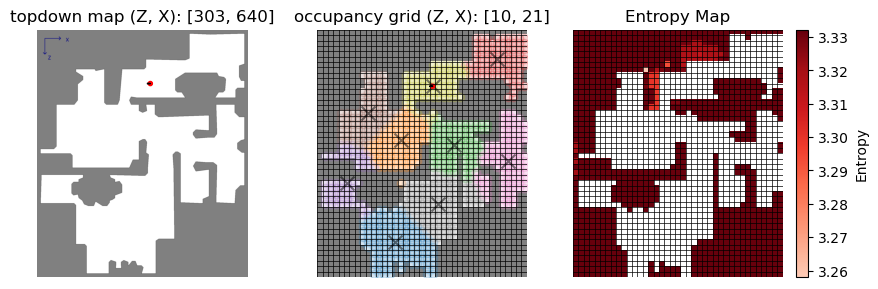

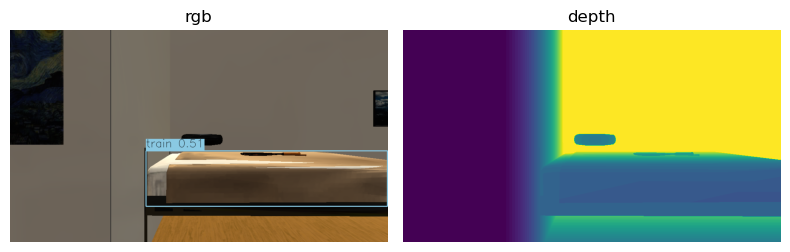

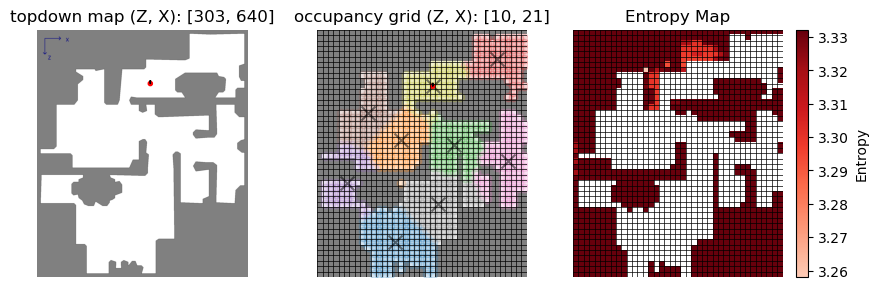

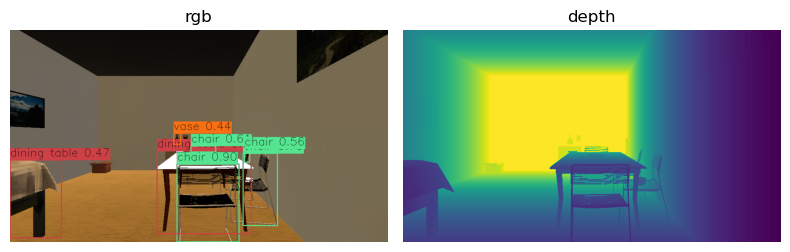

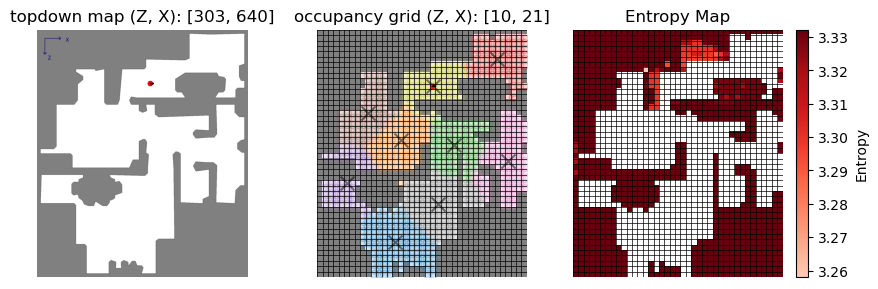

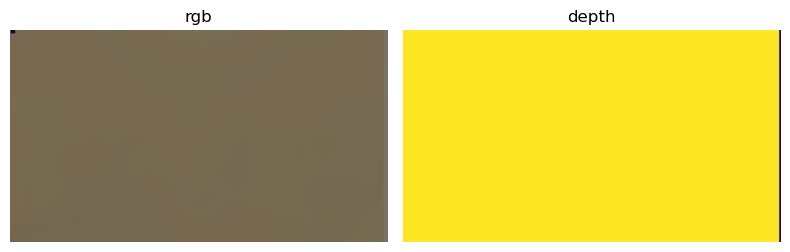

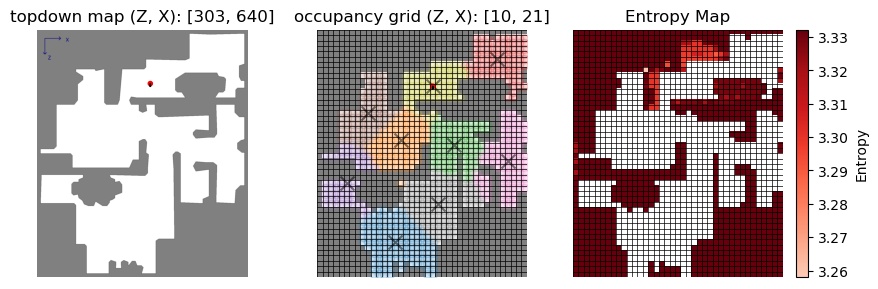

Cluster 0: Distance = 44.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 1: Distance = 16.00, Avg Entropy = 3.33047330, Avg Target Prob = 0.04
Cluster 2: Distance = 23.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 3: Distance = 17.00, Avg Entropy = 3.32843390, Avg Target Prob = 0.04
Cluster 4: Distance = 54.00, Avg Entropy = 3.33192472, Avg Target Prob = 0.04
Cluster 5: Distance = 17.00, Avg Entropy = 3.33091026, Avg Target Prob = 0.04
Cluster 6: Distance = 36.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04
Cluster 7: Distance = 31.00, Avg Entropy = 3.33220451, Avg Target Prob = 0.04

Cluster 0: Distance = 0.74, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.53
Cluster 1: Distance = 0.00, Avg Entropy = 0.54, Avg Target Prob = 0.00, Score = 0.72
Cluster 2: Distance = 0.18, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.81
Cluster 3: Distance = 0.03, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.49
Cluster 4: Distance = 1.00, Avg Ent

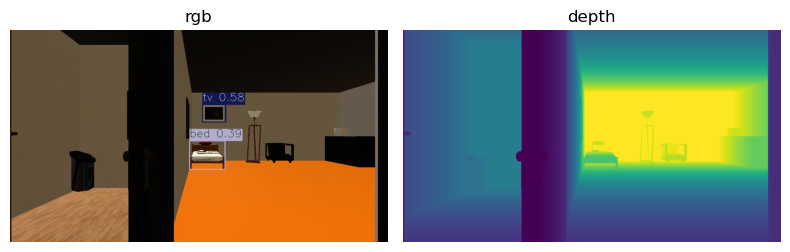

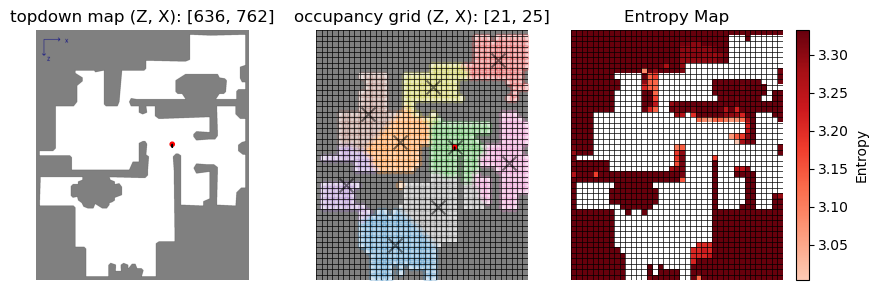

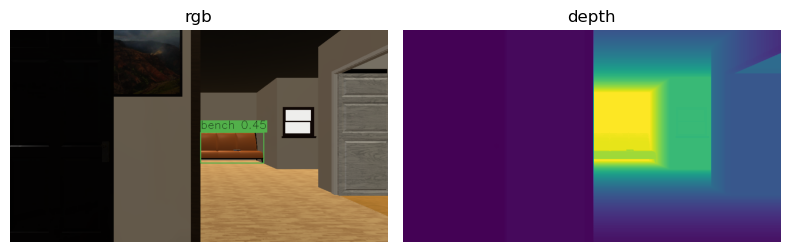

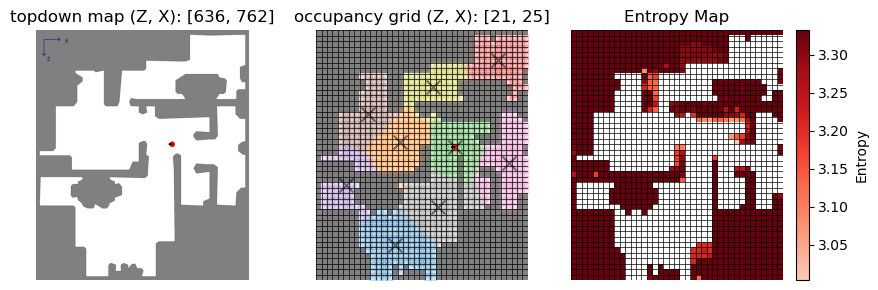

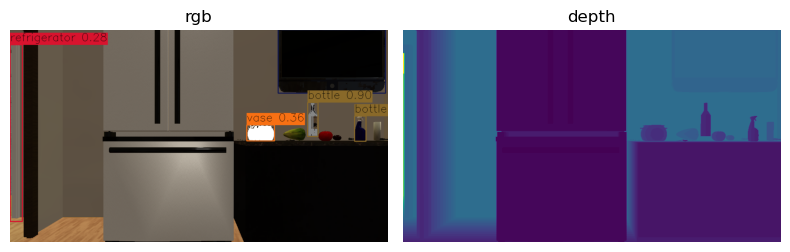

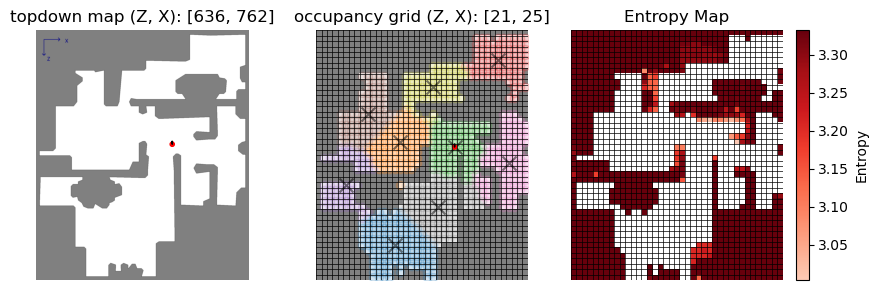

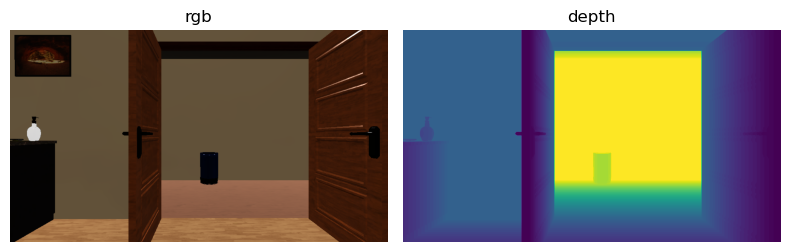

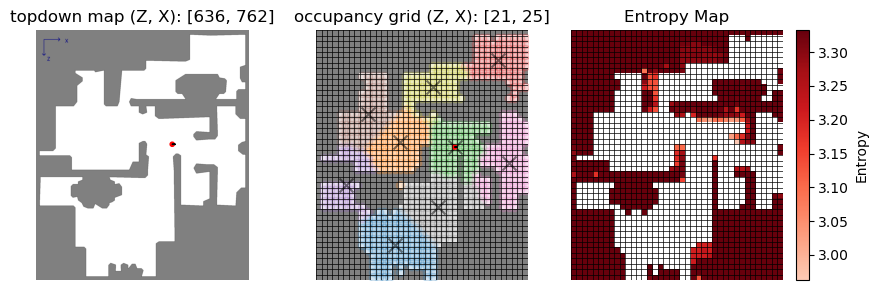

Cluster 0: Distance = 29.00, Avg Entropy = 3.32205699, Avg Target Prob = 0.04
Cluster 1: Distance = 11.00, Avg Entropy = 3.28117600, Avg Target Prob = 0.04
Cluster 2: Distance = 40.00, Avg Entropy = 3.32843390, Avg Target Prob = 0.04
Cluster 3: Distance = 39.00, Avg Entropy = 3.32962052, Avg Target Prob = 0.04
Cluster 4: Distance = 22.00, Avg Entropy = 3.32525152, Avg Target Prob = 0.04
Cluster 5: Distance = 13.00, Avg Entropy = 3.31765953, Avg Target Prob = 0.04
Cluster 6: Distance = 14.00, Avg Entropy = 3.30496972, Avg Target Prob = 0.04

Cluster 0: Distance = 0.62, Avg Entropy = 0.84, Avg Target Prob = 0.00, Score = 0.53
Cluster 1: Distance = 0.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.50
Cluster 2: Distance = 1.00, Avg Entropy = 0.98, Avg Target Prob = 0.00, Score = 0.39
Cluster 3: Distance = 0.97, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.42
Cluster 4: Distance = 0.38, Avg Entropy = 0.91, Avg Target Prob = 0.00, Score = 0.67
Cluster 5: Distance = 0.07, 

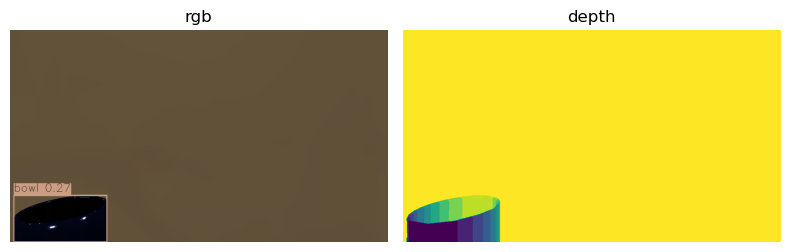

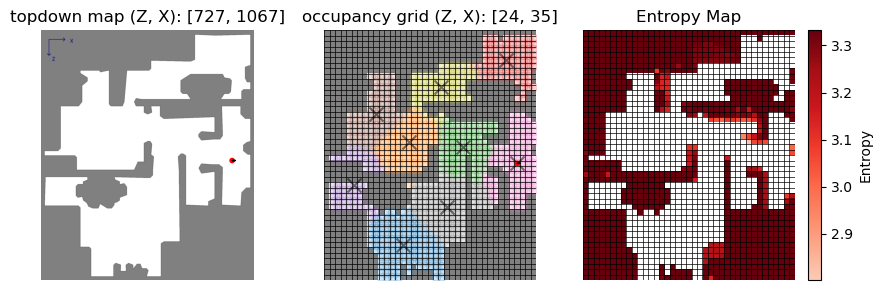

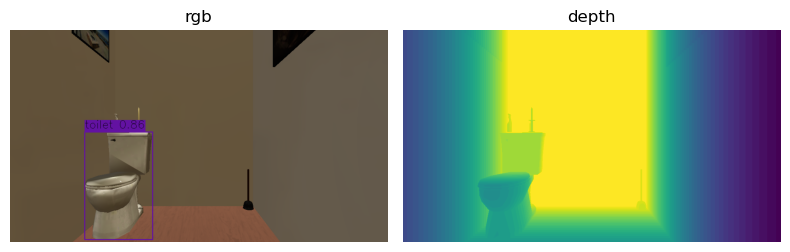

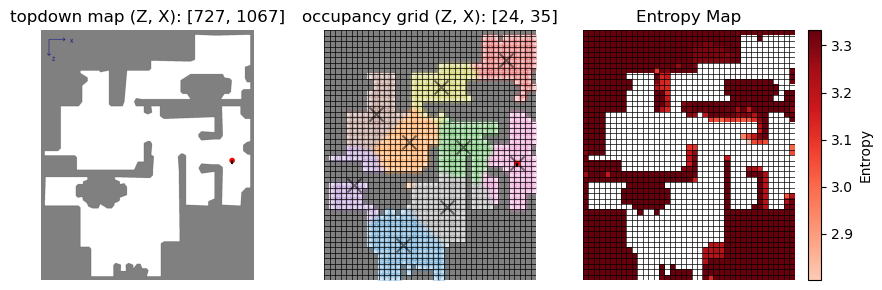

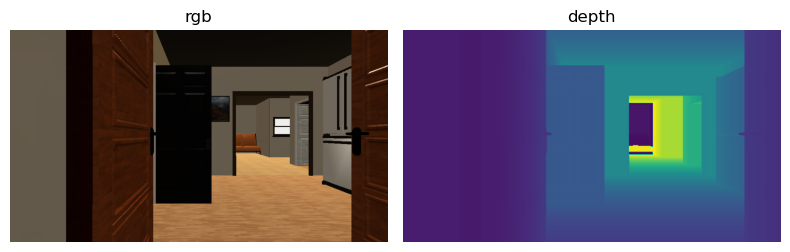

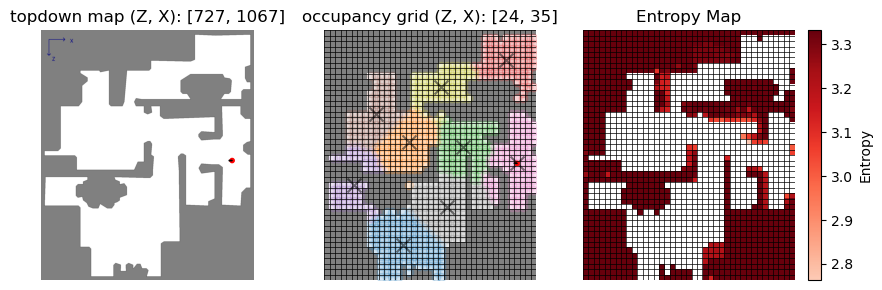

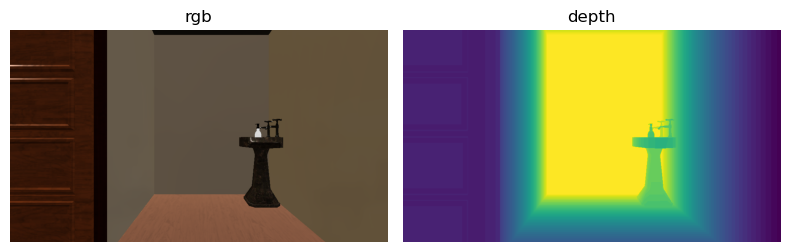

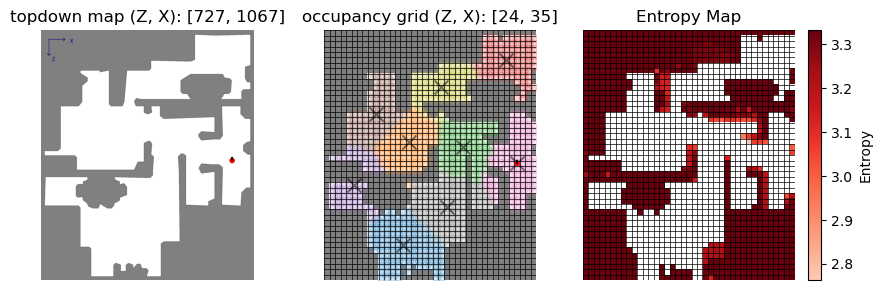

Cluster 0: Distance = 40.00, Avg Entropy = 3.32205699, Avg Target Prob = 0.04
Cluster 1: Distance = 24.00, Avg Entropy = 3.28117600, Avg Target Prob = 0.04
Cluster 2: Distance = 53.00, Avg Entropy = 3.32816562, Avg Target Prob = 0.04
Cluster 3: Distance = 50.00, Avg Entropy = 3.32962052, Avg Target Prob = 0.04
Cluster 4: Distance = 35.00, Avg Entropy = 3.32469726, Avg Target Prob = 0.04
Cluster 5: Distance = 25.00, Avg Entropy = 3.30496972, Avg Target Prob = 0.04

Cluster 0: Distance = 0.55, Avg Entropy = 0.84, Avg Target Prob = 0.00, Score = 0.56
Cluster 1: Distance = 0.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.50
Cluster 2: Distance = 1.00, Avg Entropy = 0.97, Avg Target Prob = 0.00, Score = 0.39
Cluster 3: Distance = 0.90, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.45
Cluster 4: Distance = 0.38, Avg Entropy = 0.90, Avg Target Prob = 0.00, Score = 0.67
Cluster 5: Distance = 0.03, Avg Entropy = 0.49, Avg Target Prob = 0.00, Score = 0.68

Best cluster center:

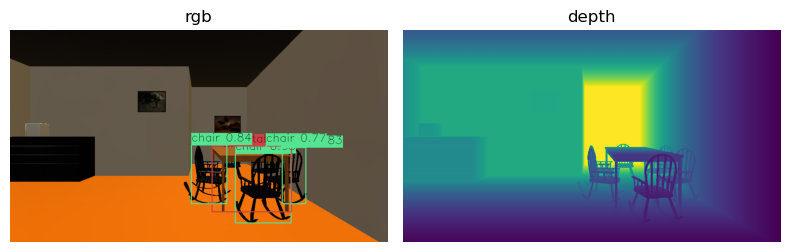

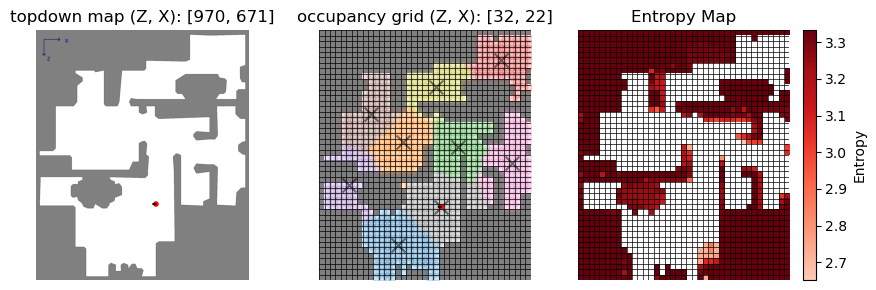

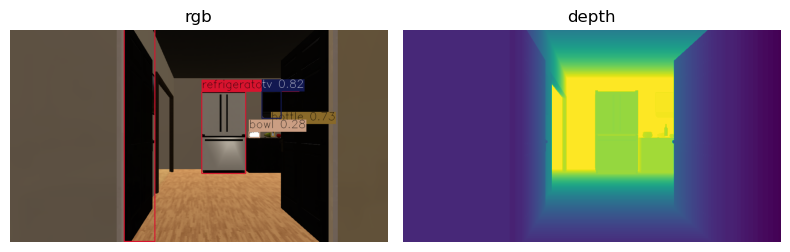

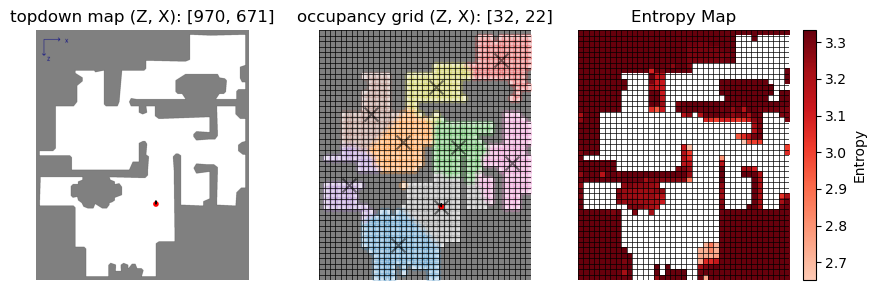

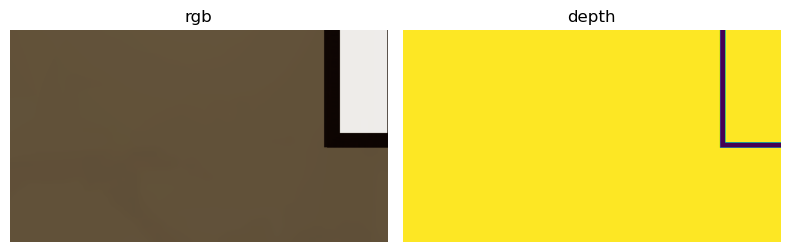

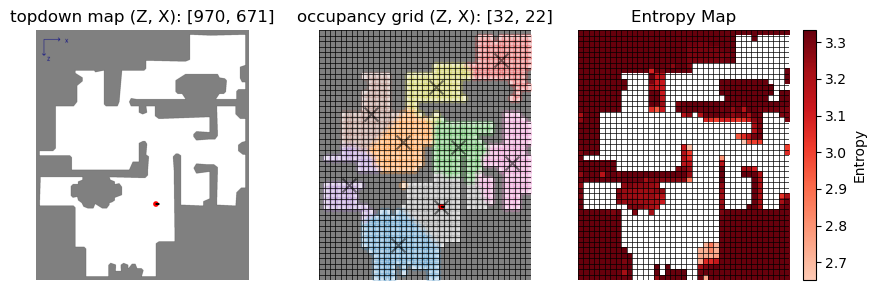

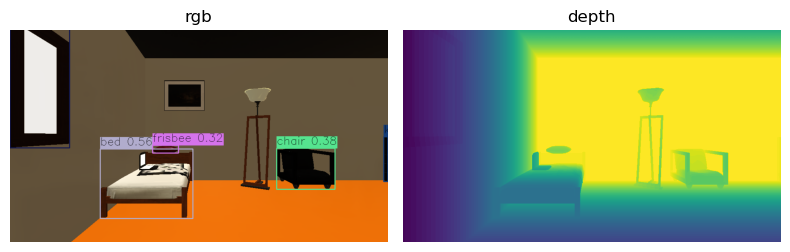

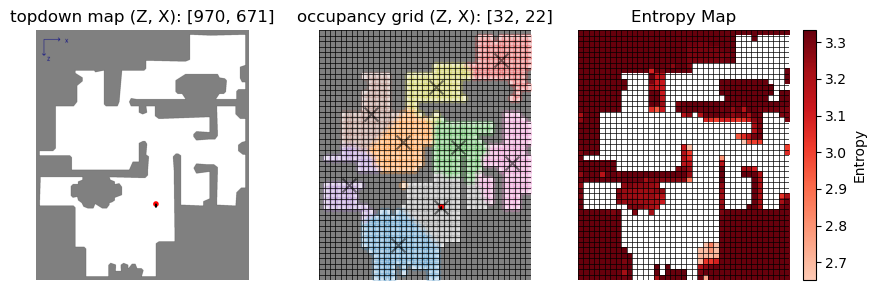

Cluster 0: Distance = 15.00, Avg Entropy = 3.25976326, Avg Target Prob = 0.04
Cluster 1: Distance = 19.00, Avg Entropy = 3.26390308, Avg Target Prob = 0.04
Cluster 2: Distance = 48.00, Avg Entropy = 3.32579923, Avg Target Prob = 0.04
Cluster 3: Distance = 25.00, Avg Entropy = 3.31215131, Avg Target Prob = 0.04
Cluster 4: Distance = 30.00, Avg Entropy = 3.31488611, Avg Target Prob = 0.04

Cluster 0: Distance = 0.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.50
Cluster 1: Distance = 0.12, Avg Entropy = 0.06, Avg Target Prob = 0.00, Score = 0.46
Cluster 2: Distance = 1.00, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.40
Cluster 3: Distance = 0.30, Avg Entropy = 0.79, Avg Target Prob = 0.00, Score = 0.67
Cluster 4: Distance = 0.45, Avg Entropy = 0.83, Avg Target Prob = 0.00, Score = 0.61

Best cluster center: [28, 5], Score = 0.67


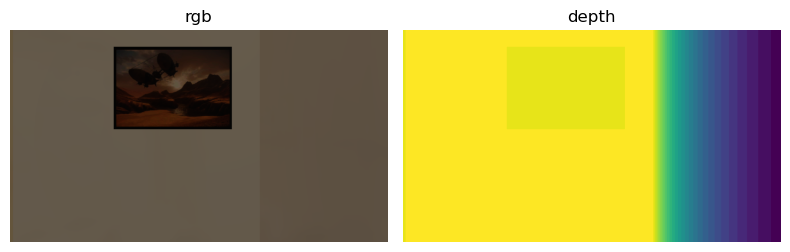

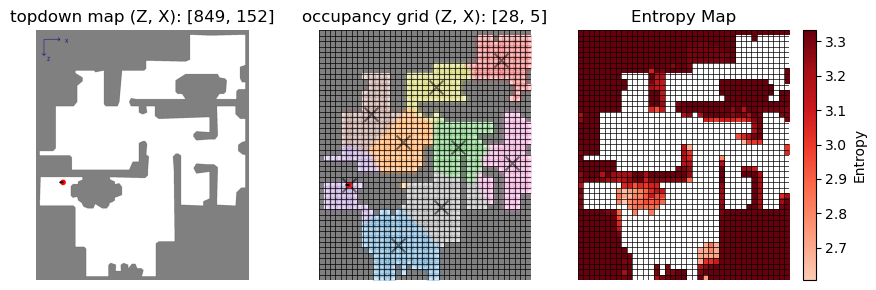

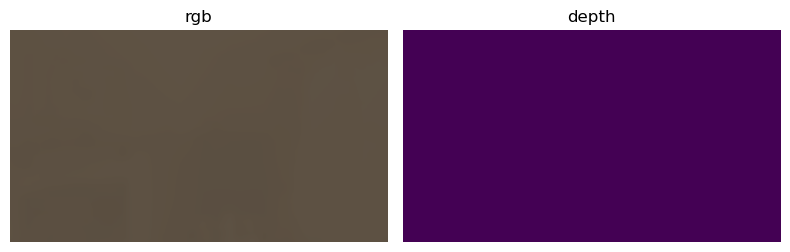

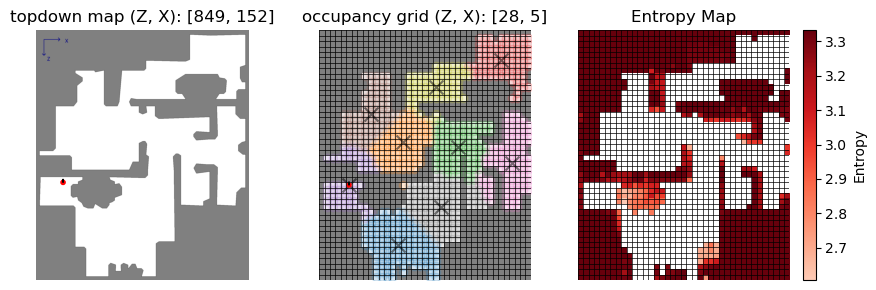

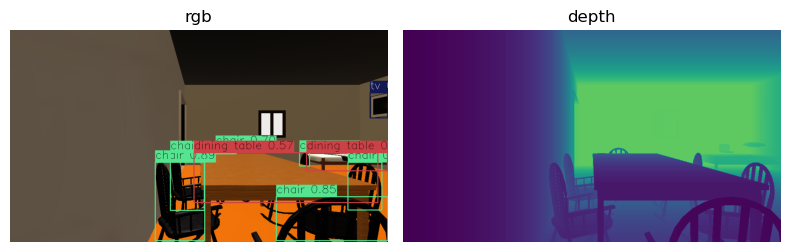

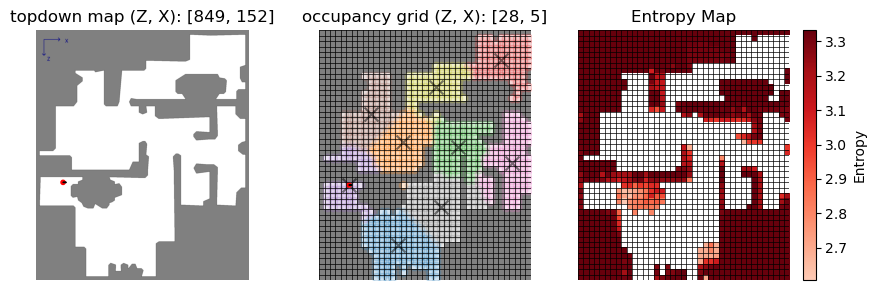

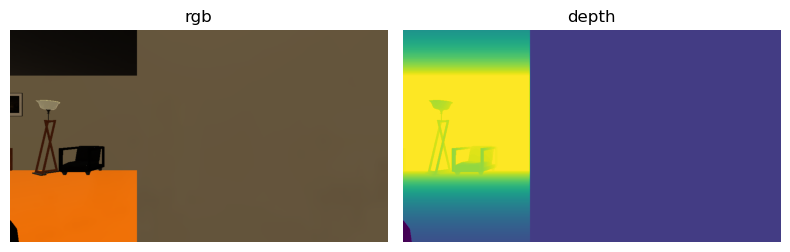

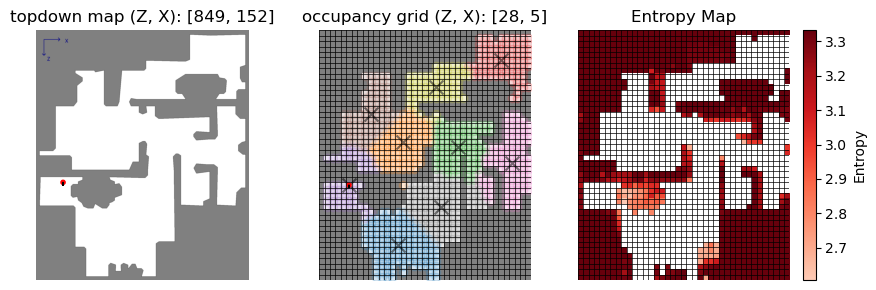

Cluster 0: Distance = 20.00, Avg Entropy = 3.20458794, Avg Target Prob = 0.04
Cluster 1: Distance = 42.00, Avg Entropy = 3.24321327, Avg Target Prob = 0.04
Cluster 2: Distance = 71.00, Avg Entropy = 3.32579923, Avg Target Prob = 0.04
Cluster 3: Distance = 53.00, Avg Entropy = 3.31488611, Avg Target Prob = 0.04

Cluster 0: Distance = 0.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.50
Cluster 1: Distance = 0.43, Avg Entropy = 0.32, Avg Target Prob = 0.00, Score = 0.41
Cluster 2: Distance = 1.00, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.40
Cluster 3: Distance = 0.65, Avg Entropy = 0.91, Avg Target Prob = 0.00, Score = 0.54

Best cluster center: [15, 9], Score = 0.54


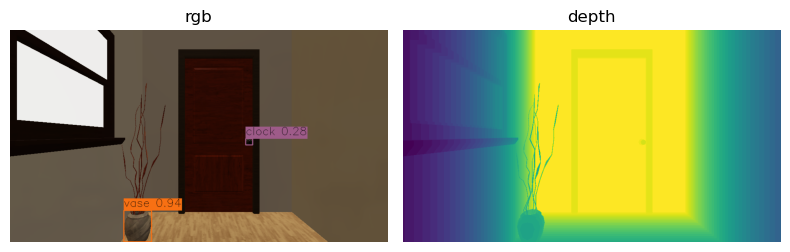

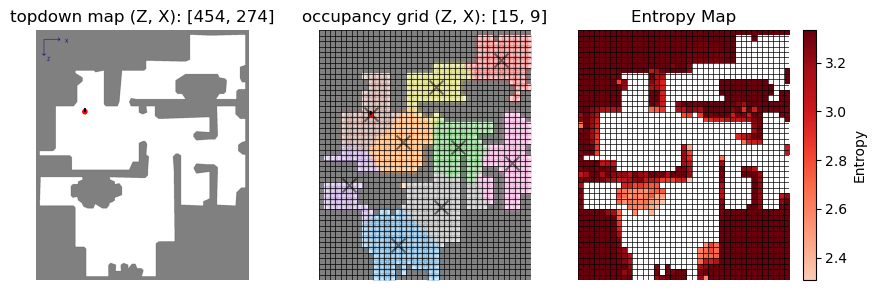

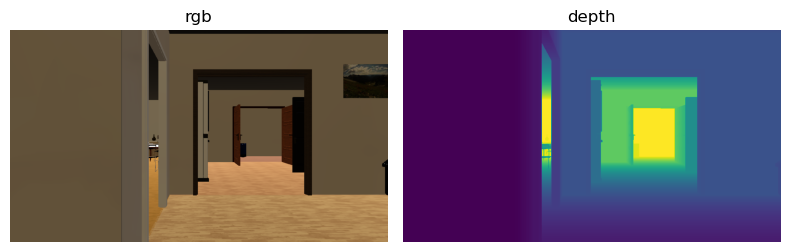

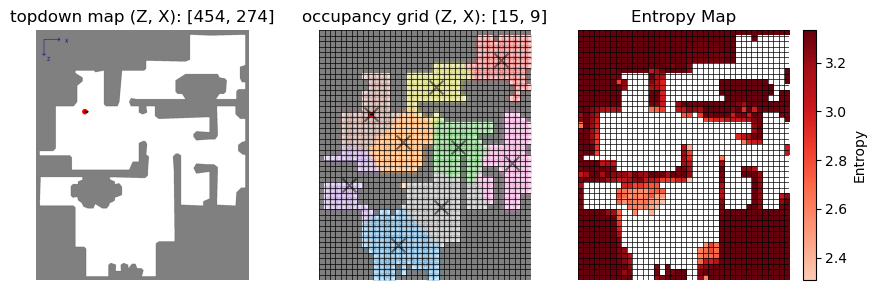

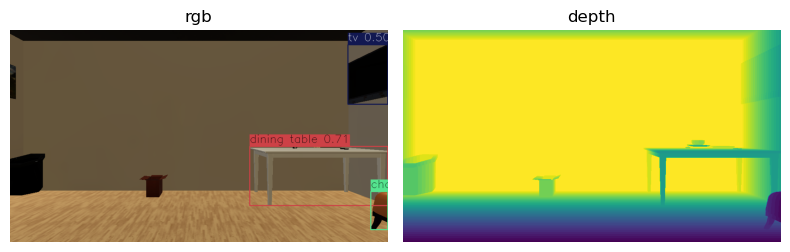

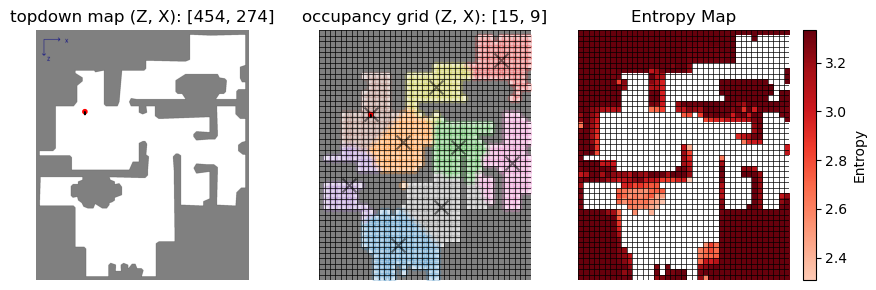

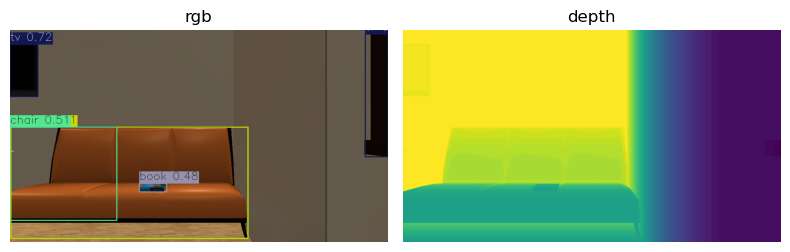

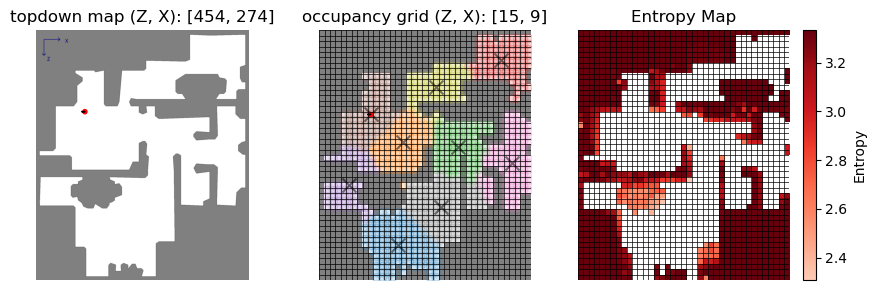

Cluster 0: Distance = 43.00, Avg Entropy = 3.12552791, Avg Target Prob = 0.04
Cluster 1: Distance = 11.00, Avg Entropy = 3.13215595, Avg Target Prob = 0.04
Cluster 2: Distance = 34.00, Avg Entropy = 3.32568415, Avg Target Prob = 0.04

Cluster 0: Distance = 1.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.00
Cluster 1: Distance = 0.00, Avg Entropy = 0.03, Avg Target Prob = 0.00, Score = 0.51
Cluster 2: Distance = 0.72, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.54

Best cluster center: [5, 33], Score = 0.54


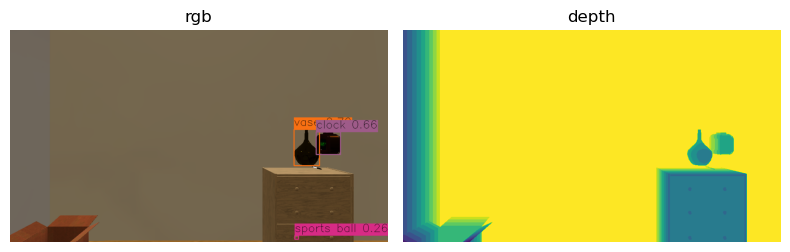

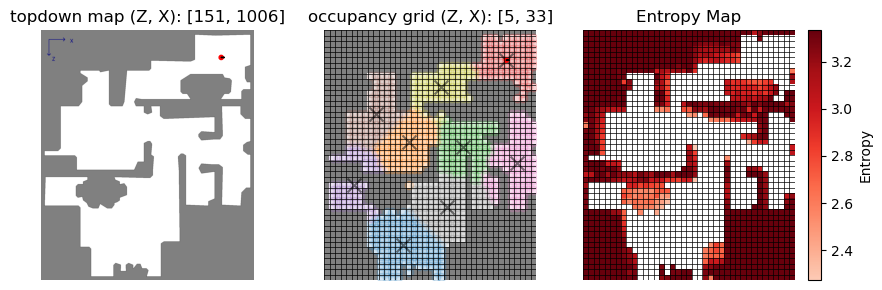

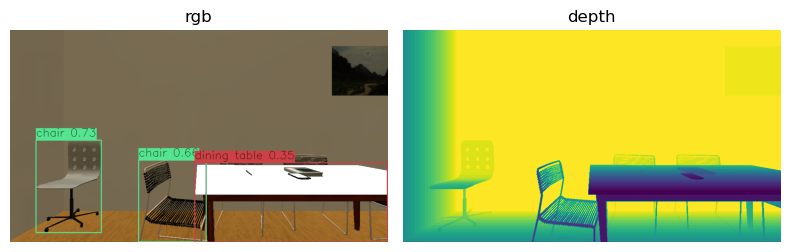

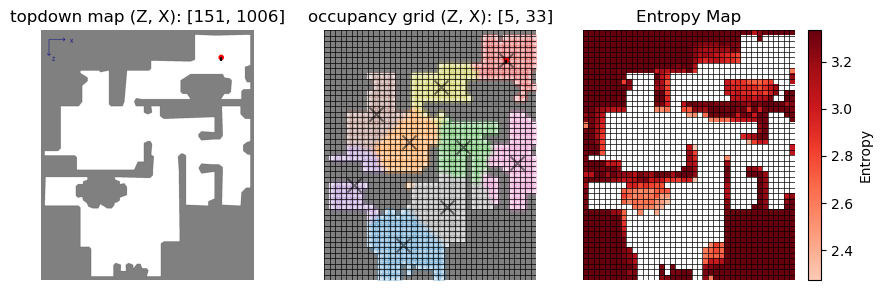

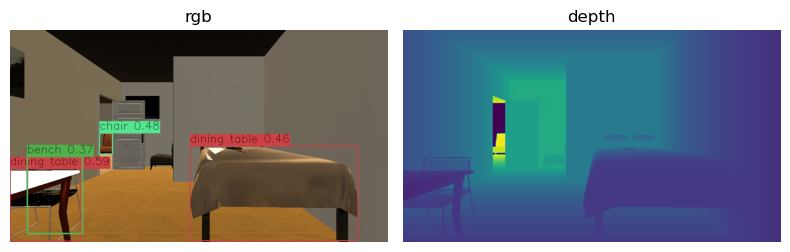

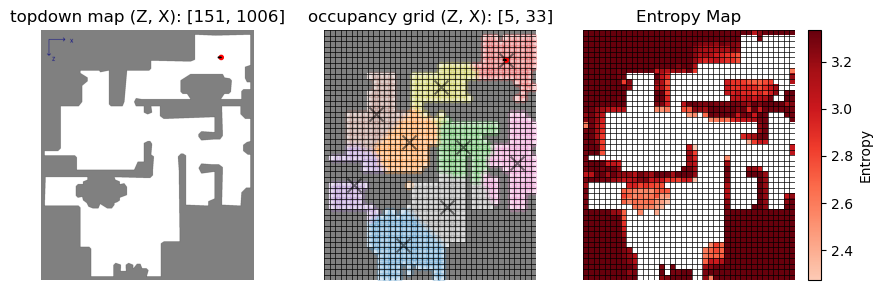

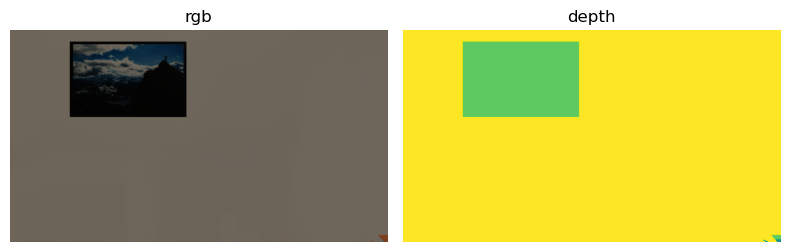

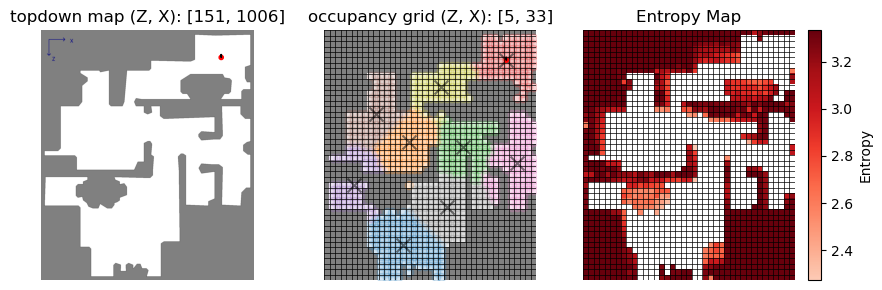

Cluster 0: Distance = 61.00, Avg Entropy = 3.12552791, Avg Target Prob = 0.04
Cluster 1: Distance = 33.00, Avg Entropy = 3.11851774, Avg Target Prob = 0.04

Cluster 0: Distance = 1.00, Avg Entropy = 1.00, Avg Target Prob = 0.00, Score = 0.40
Cluster 1: Distance = 0.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.50

Best cluster center: [20, 15], Score = 0.50


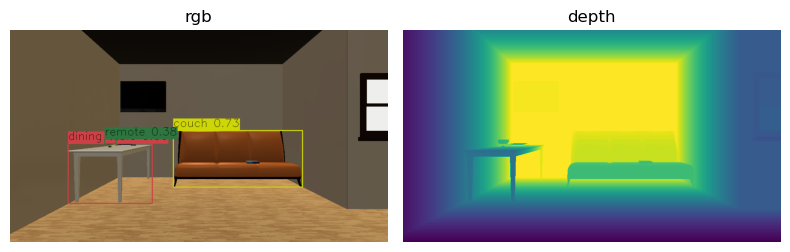

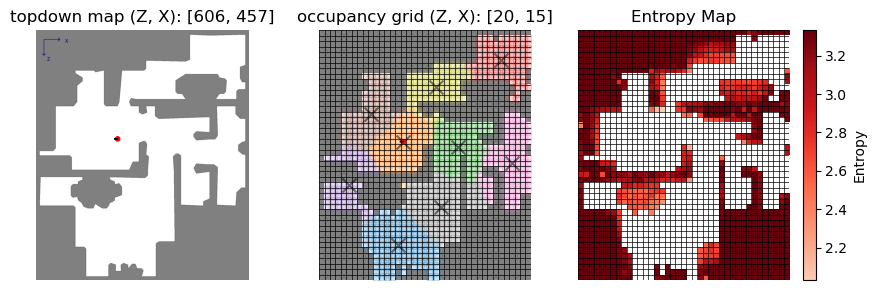

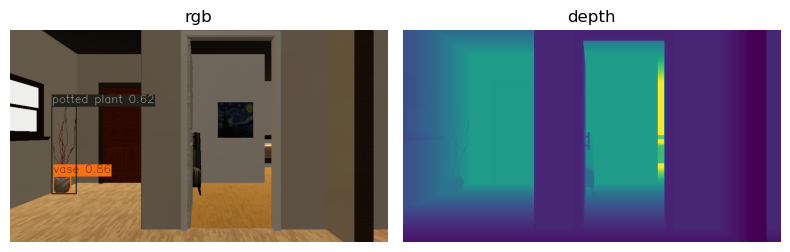

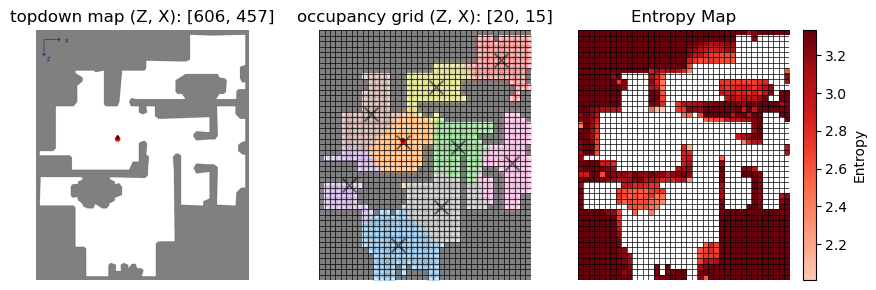

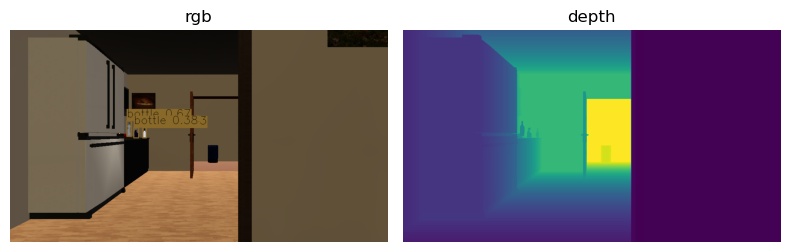

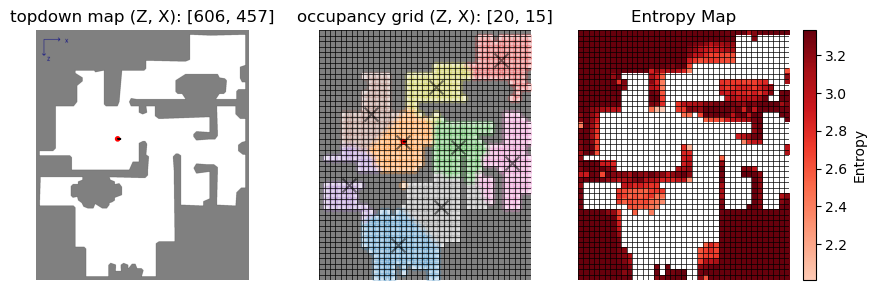

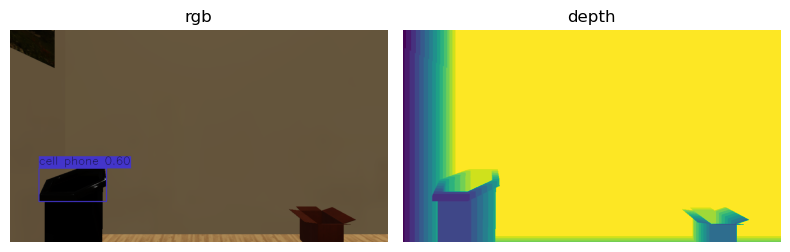

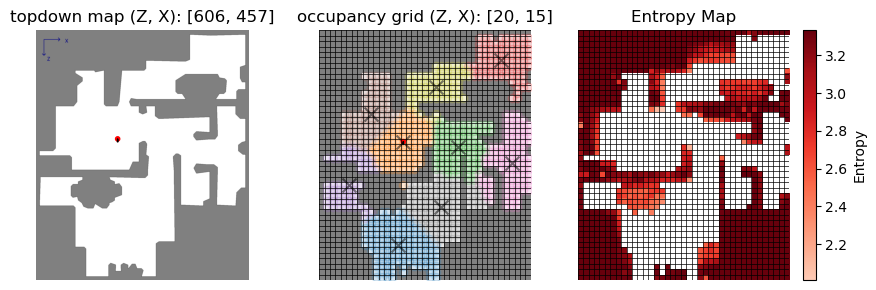

Cluster 0: Distance = 32.00, Avg Entropy = 3.12552791, Avg Target Prob = 0.04

Cluster 0: Distance = 0.00, Avg Entropy = 0.00, Avg Target Prob = 0.00, Score = 0.50

Best cluster center: [39, 14], Score = 0.50


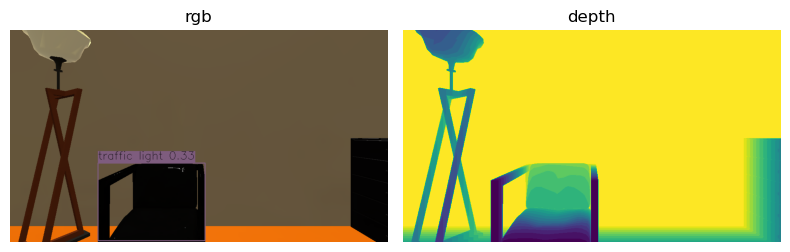

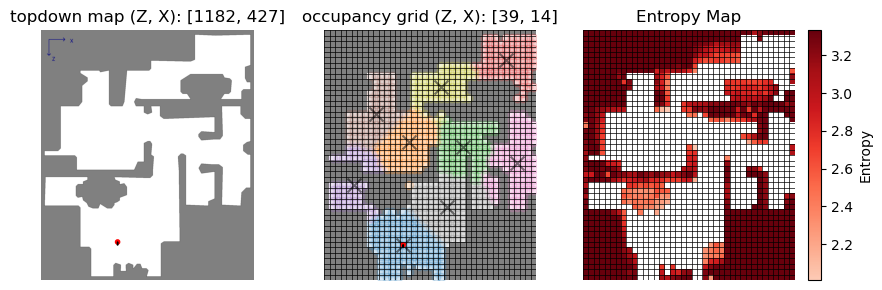

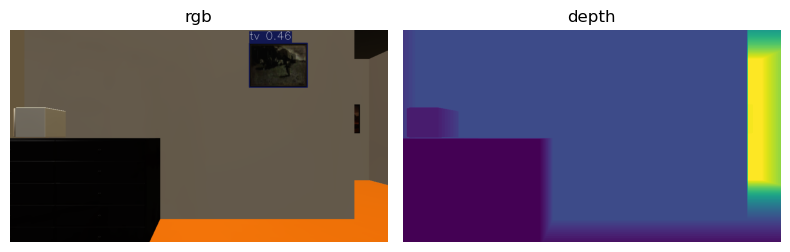

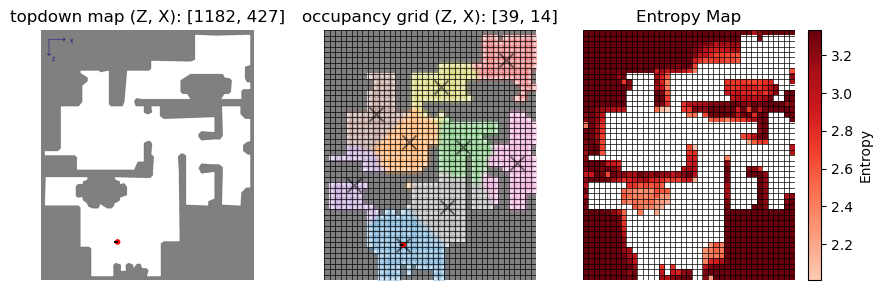

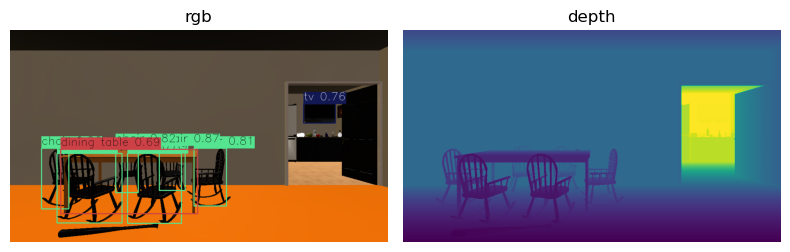

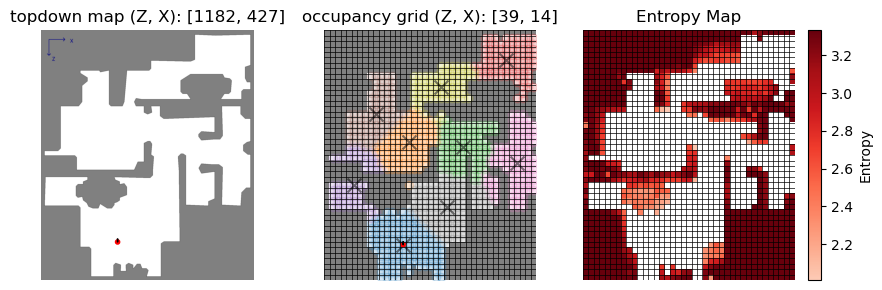

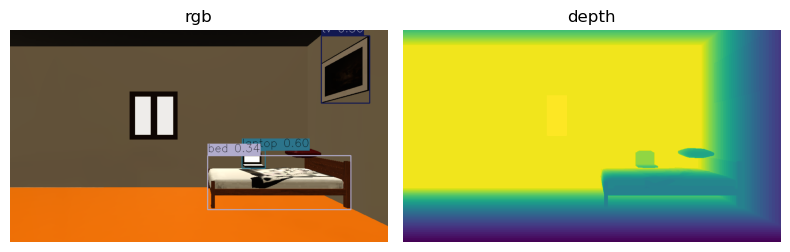

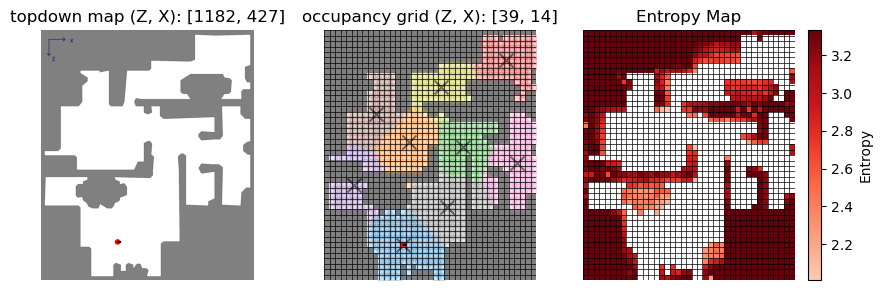

In [13]:
# Metrics init
target_found = False
num_actions = 0
travelled_distance = 0.0
location_error = float("inf")

# Simulation parameters
num_clusters = simtools.num_cluster_centers(num_free_cells, max_clusters=num_free_cells)
w_e, w_d, w_p = 0.4, 0.5, 0.1  # Weights for entropy, distance, and target probability
MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform
DISPLAY_STEP = MAX_ITER // 10  # Display every 10% of the actions

# Main simulation loop
while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
    
    # Cluster grid map
    cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
    cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
    centroids = cluster_centers.copy() # For displaying logic
    cluster_occ_cells_map = simtools.assign_cluster_centers_to_cells(grid_occ_cells, cluster_centers, grid_free_cells)

    # Entropy map
    entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

    # Display the simulation state
    simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)

    # Move into each cluster center
    while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

        # Computes scores for each cluster center
        distances, avg_entropies, avg_target_probs = [], [], []
        for cluster_center in cluster_centers:
            # Path distance 
            distance, _ = simtools.compute_path(grid_position, cluster_center, grid_free_cells)
            distances.append(distance)

            # Average entropy of the cluster
            avg_entropy = simtools.compute_average_entropy(belief_map, cluster_occ_cells_map[tuple(cluster_center)])
            avg_entropies.append(avg_entropy)

            # Target probability in the cluster surroundings
            avg_target_prob = simtools.compute_max_target_probability(belief_map, cluster_occ_cells_map[tuple(cluster_center)], indoor_objects.index(TARGET_OBJECT))
            avg_target_probs.append(avg_target_prob)

        # Print metrics for every cluster center
        for i, center in enumerate(cluster_centers):
            print(f"Cluster {i}: Distance = {distances[i]:.2f}, Avg Entropy = {avg_entropies[i]:.8f}, Avg Target Prob = {avg_target_probs[i]:.2f}")

        # Normalize score components
        distances, avg_entropies, avg_target_probs = np.array(distances), np.array(avg_entropies), np.array(avg_target_probs)
        distances = (distances-np.min(distances)) / (np.max(distances)-np.min(distances)) if np.max(distances) != np.min(distances) else np.zeros_like(distances)
        avg_entropies = (avg_entropies-np.min(avg_entropies)) / (np.max(avg_entropies)-np.min(avg_entropies)) if abs(np.max(avg_entropies) - np.min(avg_entropies)) > 1e-5 else np.zeros_like(avg_entropies)
        avg_target_probs = (avg_target_probs-np.min(avg_target_probs)) / (np.max(avg_target_probs)-np.min(avg_target_probs)) if np.max(avg_target_probs) != np.min(avg_target_probs) else np.zeros_like(avg_target_probs)

        # Select best cluster center based on the scores
        scores = w_e * avg_entropies + w_d * (1-distances) + w_p * avg_target_probs
        max_score_idx = np.argmax(scores)
        cluster_center = cluster_centers[max_score_idx]
        _, path = simtools.compute_path(grid_position, cluster_center, grid_free_cells)

        print("")
        # Print metrics for every cluster center
        for i, center in enumerate(cluster_centers):
            print(f"Cluster {i}: Distance = {distances[i]:.2f}, Avg Entropy = {avg_entropies[i]:.2f}, Avg Target Prob = {avg_target_probs[i]:.2f}, Score = {scores[i]:.2f}")

        # Print best cluster center
        print(f"\nBest cluster center: {cluster_center}, Score = {scores[max_score_idx]:.2f}")

        # Move through the path
        while (path) and (num_actions < MAX_ITER) and (not target_found):
            
            # Compute actions to move to next path cell
            action_list = simtools.compute_relative_actions(grid_position, agent_yaw, path[0], ACTIONS)

            # Perform the rotation action, if needed
            for action in action_list:

                # Perform action
                grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                idx = grid_free_cells.index(grid_position)
                map_position, world_position = map_free_cells[idx], world_free_coords[idx]
                agent_positions = (map_position, grid_position)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)

                # Update metrics
                num_actions += 1
                travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

                # Update agent state
                agent_state.position = world_position
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Get observations
                obs = sim.get_sensor_observations(0)
                rgb, depth = obs["color_sensor"], obs["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                
                # Initialize processed cells
                processed_cells = []

                # Process the observations
                for det in detections:
                    box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                    scale = myutils.compute_bbox_scale(box, rgb)

                    # Center of bbox and depth value
                    center_x, center_y = simtools.get_box_center(box)
                    depth_value = depth[center_y, center_x]

                    # Project to real world, grid and map coords
                    camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                    object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                    object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                    # Check if projected cell is outside free grid cells
                    if object_grid_position in grid_free_cells:
                        object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                    # Add this cell to processed cells
                    if tuple(object_grid_position) not in processed_cells:
                        processed_cells.append(tuple(object_grid_position))

                    # Likelihood vector: likelihood of each class (Rule 1)
                    likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                    # Kaplan Update to the belief map in that cell
                    grid_x, grid_y = object_grid_position
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Compute every theoretically visible occupied cell
                rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
               
                # Go through every visible occupied cell and update the belief map
                for cell in visible_occ_cells:
                    if tuple(cell) not in processed_cells:

                        # Compute distance to the cell
                        grid_x, grid_y = cell
                        distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                        # Compute the likelihood vector for the cell (Rule 2)
                        likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                        # Kaplan update to the belief map in that cell
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Entropy map
                entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

                # Check if target was found
                if target_found: break

            # Remove the path cell
            path.pop(0)

        # Check if target was found
        if target_found: break

        # When in cluster center, rotate 3 times to get the full 360 degrees view
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)
        for i in range(3):
            grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
            agent_quart = myutils.yaw_to_quaternion(agent_yaw)
            agent_state.rotation = agent_quart
            agent.set_state(agent_state)

            # Update metrics
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            detections = simtools.parse_yolo_detections(results)
            simtools.merge_rgb_yolo_outputs(rgb, detections)
            target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

            # Initialize processed cells
            processed_cells = []

            # Process the observations
            for det in detections:
                box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                scale = myutils.compute_bbox_scale(box, rgb)

                # Center of bbox and depth value
                center_x, center_y = simtools.get_box_center(box)
                depth_value = depth[center_y, center_x]

                # Project to real world, grid and map coords
                camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                # Check if projected cell is outside free grid cells
                if object_grid_position in grid_free_cells:
                    object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                # Add this cell to processed cells
                if tuple(object_grid_position) not in processed_cells:
                    processed_cells.append(tuple(object_grid_position))

                # Likelihood vector: likelihood of each class (Rule 1)
                likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                # Kaplan Update to the belief map in that cell
                grid_x, grid_y = object_grid_position
                belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

            # Compute every theoretically visible occupied cell
            rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
            visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)

            # Go through every visible occupied cell and update the belief map
            for cell in visible_occ_cells:
                if tuple(cell) not in processed_cells:

                    # Compute distance to the cell
                    grid_x, grid_y = cell
                    distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                    # Compute the likelihood vector for the cell (Rule 2)
                    likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                    # Kaplan update to the belief map in that cell
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

            # Entropy map
            entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

            simtools.display_sim_observations(rgb, depth)
            simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)
            # Check if target was found
            if target_found: break 

        # Remove cluster center
        cluster_centers.remove(cluster_center)

    # Double the number of clusters if all clusters were visited
    num_clusters *= 2


Target object <laptop> found after 361 actions!
Found location: [    -4.2627     0.41891      12.707]
Real location: [-4.388556361332703, 0.46572605818735285, 12.68326727300861]


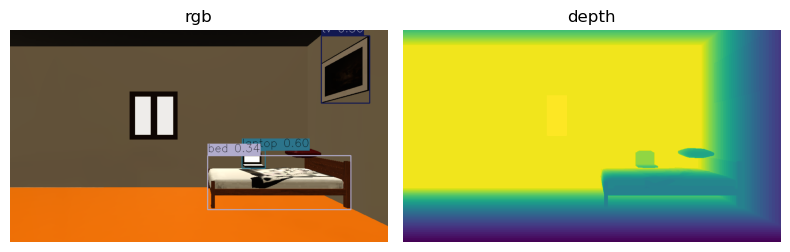

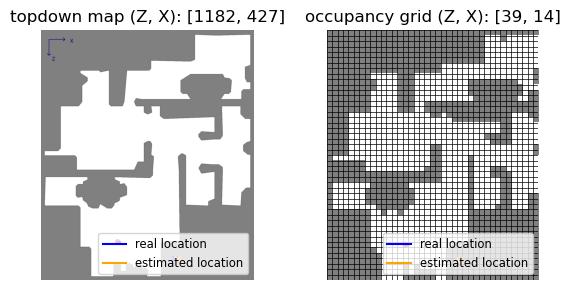

Number of actions: 361
Travelled distance: 73.38 m
Computed localization error: 0.128 m


In [15]:
# Target found or not
if target_found:
    # Real world position 
    center_x, center_y = simtools.get_box_center(target_bbox)
    depth_value = depth[center_y, center_x]
    target_object_position = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # Location_error to the target location
    location_error = simtools.compute_location_error(target_object_position, REAL_TARGET_LOCATION)

    # Check if location is valid
    if location_error > LOCATION_ERROR_THRESHOLD:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions, but location error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
        target_found = False
        location_error = float("inf")
else:
    # At this point, if target was not found, it might have been observed but without enough confidence. Check the target probability in the entropy map.
    target_found, target_grid_position = simtools.check_target_probability_in_entropy_map(belief_map, grid_cells, indoor_objects.index(TARGET_OBJECT), PSEUDO_COUNT_THRESHOLD)

    if target_found:
        # Convert target grid position to real world coordinates
        target_object_position = world_coords[grid_cells.index(target_grid_position)]
        target_map_position = map_cells[grid_cells.index(target_grid_position)]

        # Location_error to the target location
        location_error = simtools.compute_location_error(target_object_position, REAL_TARGET_LOCATION)

        # Check if location is valid
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions, but location error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False
            location_error = float("inf")

            print(f"Found location: {target_object_position}")
            print(f"Real location: {REAL_TARGET_LOCATION}")

            target_real_map_position, target_real_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
            target_2d_coords = (target_map_position, target_grid_position)
            target_real_2d_coords = (target_real_map_position, target_real_grid_position)
            target_coords = (target_real_2d_coords, target_2d_coords)

            simtools.display_sim_observations(rgb, depth)
            simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_coords)
    
if target_found:
    # Process data
    target_real_map_position, target_real_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
    target_map_position, target_grid_position = simtools.get_2d_coords(target_object_position, topdown_resolution, grid_resolution, sim.pathfinder)
    target_2d_coords = (target_map_position, target_grid_position)
    target_real_2d_coords = (target_real_map_position, target_real_grid_position)
    target_coords = (target_real_2d_coords, target_2d_coords)

    # Print results
    print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    print(f"Found location: {target_object_position}")
    print(f"Real location: {REAL_TARGET_LOCATION}")
    simtools.display_sim_observations(rgb, depth)
    simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_coords)
else:
    print(f"\nTarget object <{TARGET_OBJECT}> not found after {MAX_ITER} actions!")
    print(f"Real location: {REAL_TARGET_LOCATION}")

# Display simulation metrics
print(f"Number of actions: {num_actions}")
print(f"Travelled distance: {travelled_distance:.2f} m")
print(f"Computed localization error: {location_error:.3f} m")